# 02 — A visual tour of USDA livestock prices

Five monthly `USD/cwt` series — fed cattle, heavy feeder cattle, boxed beef
(Choice and Select cutouts), and pork cutout composite — viewed four ways:

1. **Time series with event annotations** — what the level looks like, what
   the major shocks were
2. **Seasonal decomposition** (statsmodels) — separating trend, annual
   seasonality, and residual
3. **Year-over-year change** — what the cycle looks like in growth-rate terms
4. **Cross-series correlations** — how tightly the prices move together at
   monthly frequency

Run order: top to bottom. Assumes `data/clean/observations.parquet` exists.


In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import polars as pl
from statsmodels.tsa.seasonal import seasonal_decompose

from usda_sandbox.store import read_observations, read_series


def find_project_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for candidate in [p, *p.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Could not find project root")


PROJECT_ROOT = find_project_root()
OBS_PATH = PROJECT_ROOT / "data" / "clean" / "observations.parquet"

SELECTED_SERIES: list[tuple[str, str]] = [
    ("cattle_steer_choice_nebraska", "NE Steers (Choice 65-80%)"),
    ("cattle_feeder_steer_750_800", "Feeder steers, 750-800 lbs (OK)"),
    ("boxed_beef_cutout_choice", "Boxed beef cutout — Choice"),
    ("boxed_beef_cutout_select", "Boxed beef cutout — Select"),
    ("pork_cutout_composite", "Pork cutout composite"),
]
SELECTED_IDS = [sid for sid, _ in SELECTED_SERIES]
LABELS = dict(SELECTED_SERIES)

# Annotated events — dates picked to anchor narrative, not for surgical precision
EVENTS: list[tuple[str, str]] = [
    ("2008-09-01", "Financial crisis"),
    ("2014-11-01", "2014-15 cattle peak"),
    ("2020-04-01", "COVID slaughter shock"),
    ("2022-03-01", "Russia/Ukraine commodity spike"),
    ("2025-06-01", "2024-25 cycle high"),
]


## 1. Five series at a glance, with event markers

Each chart is on its own y-axis (the levels span ~$60 to ~$500/cwt across
species), so absolute scales aren't comparable across panels — but the shape
of the cycles is.

In [2]:
def add_events(fig: go.Figure) -> None:
    for date_str, label in EVENTS:
        fig.add_vline(
            x=date_str,
            line_width=1,
            line_dash="dot",
            line_color="rgba(120,120,120,0.6)",
        )
        fig.add_annotation(
            x=date_str,
            yref="paper",
            y=1.02,
            text=label,
            showarrow=False,
            font=dict(size=10, color="gray"),
            xanchor="left",
        )


for sid, name in SELECTED_SERIES:
    s = (
        read_series(sid, OBS_PATH)
        .filter(pl.col("value").is_not_null())
        .sort("period_start")
    )
    fig = go.Figure(
        go.Scatter(
            x=s["period_start"].to_list(),
            y=s["value"].to_list(),
            mode="lines",
            name=name,
            line=dict(width=1.6),
        )
    )
    fig.update_layout(
        title=f"{name} — monthly, USD/cwt",
        xaxis_title="Period",
        yaxis_title="USD/cwt",
        height=380,
        margin=dict(t=60, b=40),
        hovermode="x unified",
    )
    add_events(fig)
    fig.show()


## 2. Seasonal decomposition

Multiplicative decomposition with a 12-month period. The four panels show:

- **Observed** — the series itself
- **Trend** — moving-average smoothed level
- **Seasonal** — recurring annual pattern (multiplicative ratio: 1.0 = no
  seasonal effect, 1.05 = 5% above trend in that month)
- **Residual** — what's left after removing trend and seasonality. Big
  residuals are the "shocks" that won't be in next year's seasonal pattern.

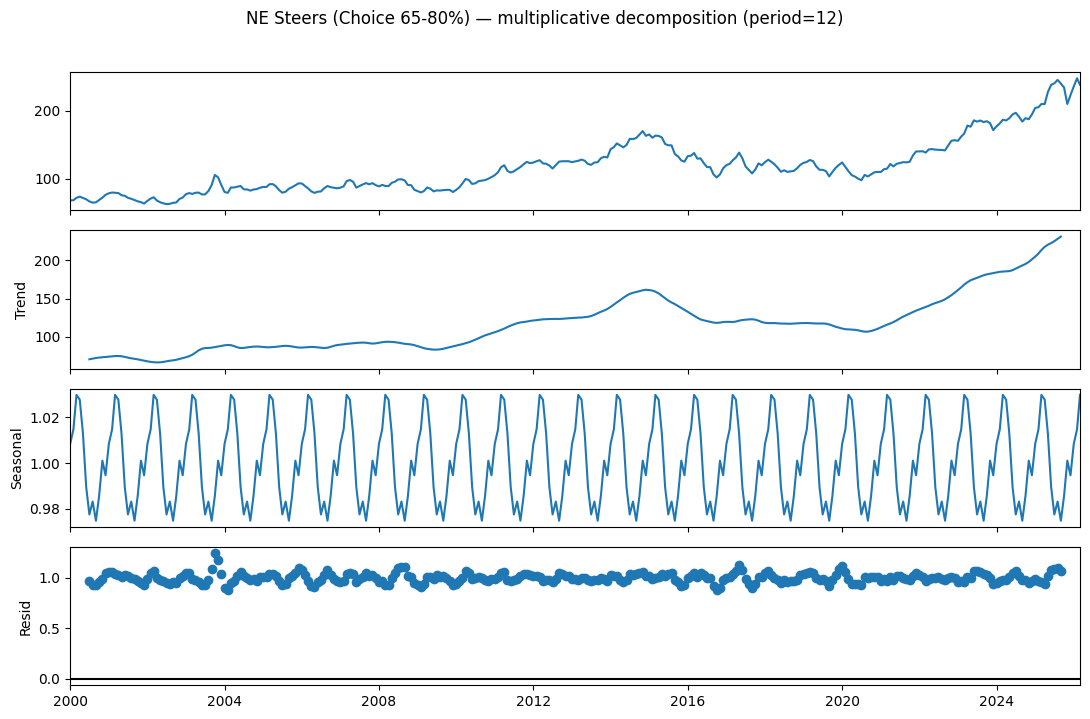

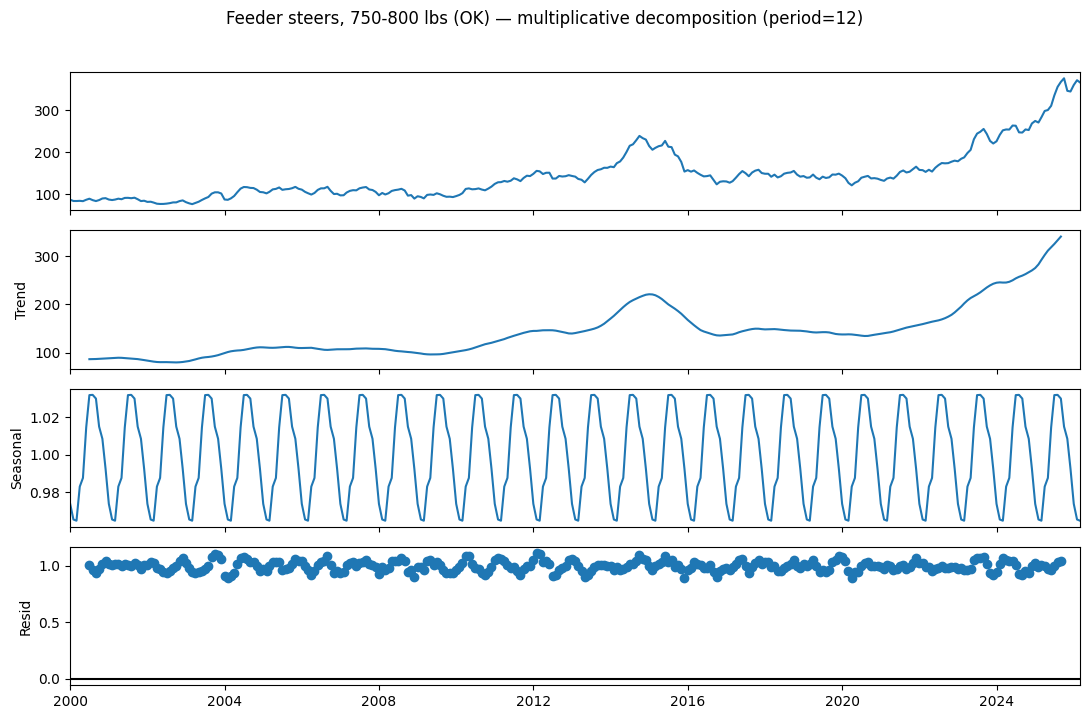

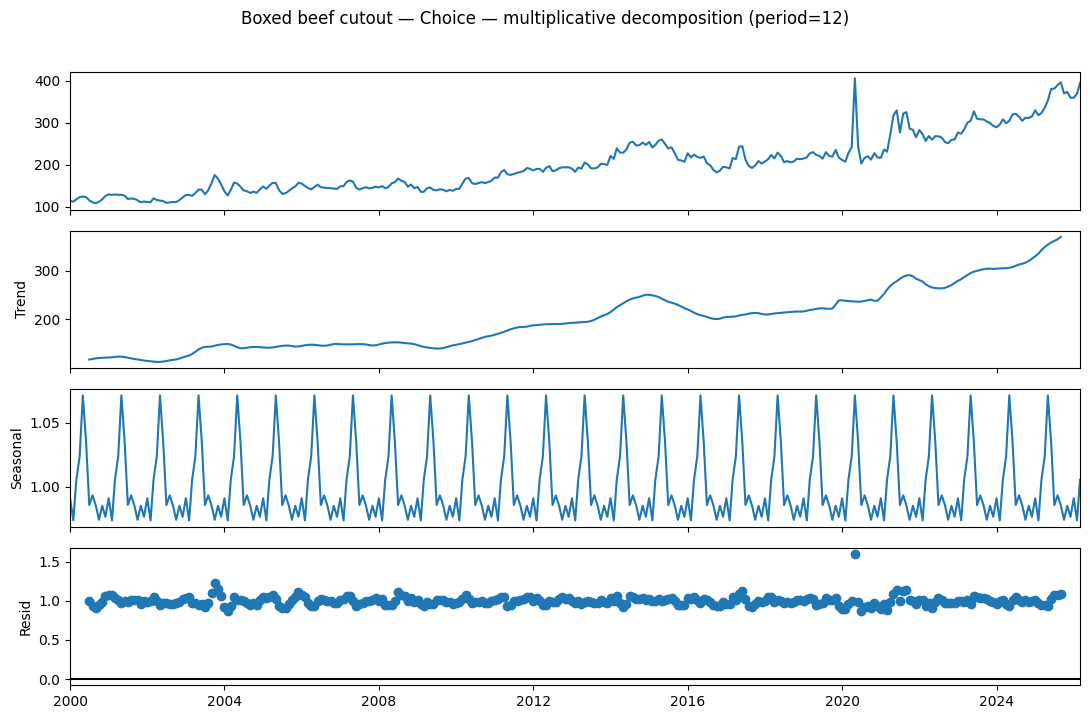

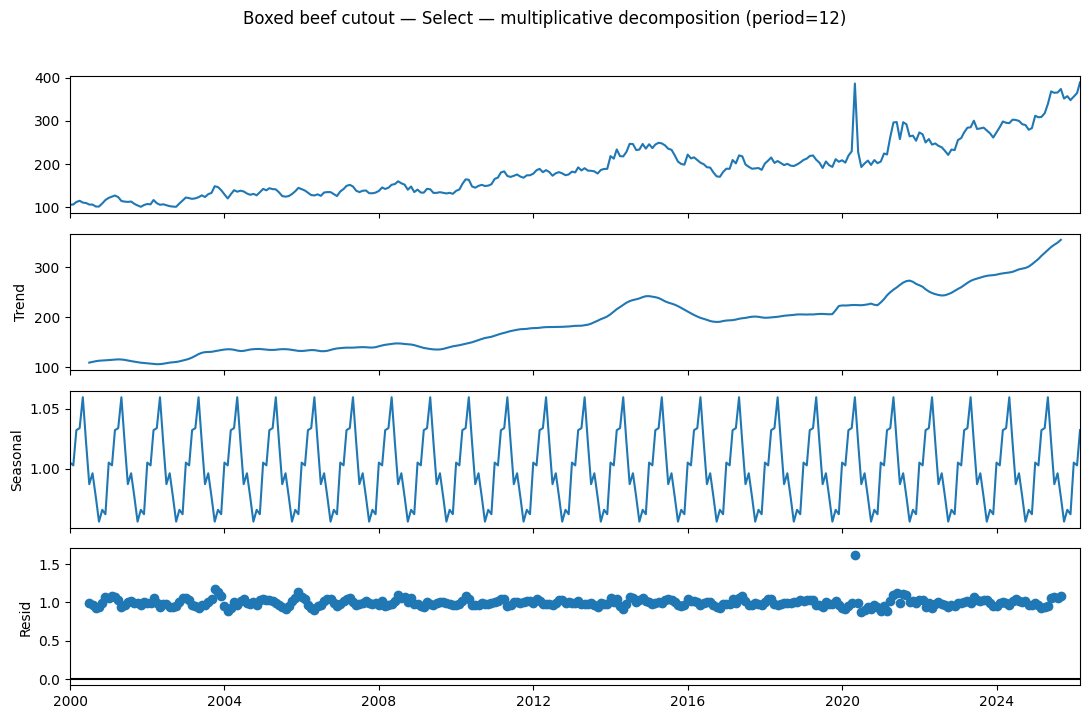

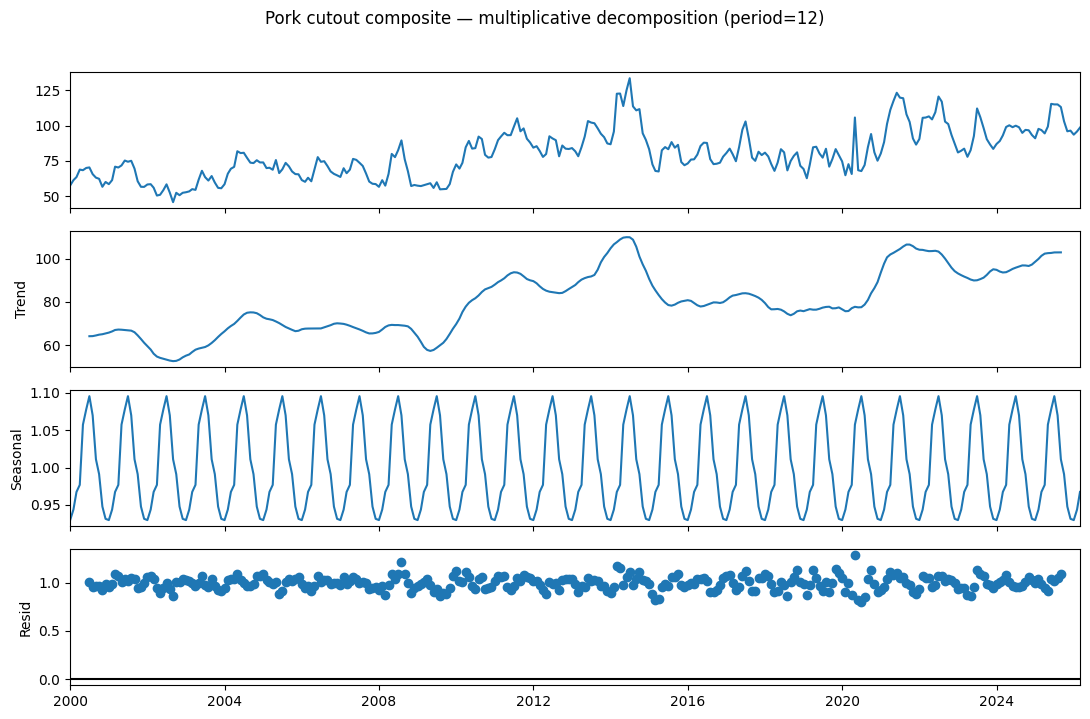

In [3]:
def decompose_and_plot(series_id: str, label: str) -> None:
    s = (
        read_series(series_id, OBS_PATH)
        .filter(pl.col("value").is_not_null())
        .sort("period_start")
    )
    pdf = s.to_pandas()
    ts = pd.Series(
        pdf["value"].to_numpy(dtype=float),
        index=pd.DatetimeIndex(pdf["period_start"]),
    ).asfreq("MS")
    # Single-null forward-fill for series with sporadic gaps (NE steers has 1)
    ts = ts.ffill()

    result = seasonal_decompose(ts, model="multiplicative", period=12)
    fig = result.plot()
    fig.set_size_inches(11, 7)
    fig.suptitle(f"{label} — multiplicative decomposition (period=12)", y=1.02)
    plt.tight_layout()
    plt.show()


for sid, name in SELECTED_SERIES:
    decompose_and_plot(sid, name)


## 3. Year-over-year change

Twelve-month percent change strips out level differences and shows the
**rate** at which prices are accelerating or decelerating. Cattle prices
spend long stretches at +20% YoY (a hot cycle) and -10% YoY (a cold cycle);
COVID-era pork shows up as a sharp -30% spike in 2020.

In [4]:
yoy_long = (
    read_observations(OBS_PATH)
    .filter(pl.col("series_id").is_in(SELECTED_IDS))
    .filter(pl.col("value").is_not_null())
    .sort(["series_id", "period_start"])
    .with_columns(
        yoy_pct=(
            (pl.col("value") / pl.col("value").shift(12).over("series_id") - 1)
            * 100
        ).round(2)
    )
    .filter(pl.col("yoy_pct").is_not_null())
    .collect()
)

fig = go.Figure()
for sid, name in SELECTED_SERIES:
    sub = yoy_long.filter(pl.col("series_id") == sid)
    fig.add_trace(
        go.Scatter(
            x=sub["period_start"].to_list(),
            y=sub["yoy_pct"].to_list(),
            mode="lines",
            name=name,
            line=dict(width=1.4),
        )
    )

fig.add_hline(y=0, line_width=1, line_color="rgba(0,0,0,0.4)")
fig.update_layout(
    title="Year-over-year price change (%) — 12-month percent change",
    xaxis_title="Period",
    yaxis_title="YoY change, %",
    height=520,
    hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=-0.35, xanchor="left", x=0),
)
add_events(fig)
fig.show()


## 4. Cross-series correlations

Pearson correlation of monthly levels for the five series. Numbers near
**+1.0** mean the series move together; numbers near **0** mean they drift
independently. Expect the two boxed-beef grades and the two cattle series
to cluster tightly; pork should be loosely correlated.

In [5]:
wide = (
    read_observations(OBS_PATH)
    .filter(pl.col("series_id").is_in(SELECTED_IDS))
    .filter(pl.col("value").is_not_null())
    .select(["series_id", "period_start", "value"])
    .collect()
    .pivot(values="value", index="period_start", on="series_id")
    .sort("period_start")
    .drop_nulls()
)

# Pretty labels
display_columns = {sid: LABELS[sid] for sid in SELECTED_IDS if sid in wide.columns}
corr = wide.drop("period_start").rename(display_columns).to_pandas().corr()

fig = px.imshow(
    corr.round(2),
    text_auto=True,
    color_continuous_scale="RdBu_r",
    zmin=-1,
    zmax=1,
    aspect="auto",
    title=f"Monthly price correlations (n = {wide.height} observations)",
)
fig.update_layout(height=520, margin=dict(t=60, b=20))
fig.show()


In [6]:
# Print the underlying numbers for reference
print(corr.round(3))


                                 Boxed beef cutout — Choice  \
Boxed beef cutout — Choice                            1.000   
Boxed beef cutout — Select                            0.996   
Feeder steers, 750-800 lbs (OK)                       0.899   
NE Steers (Choice 65-80%)                             0.928   
Pork cutout composite                                 0.737   

                                 Boxed beef cutout — Select  \
Boxed beef cutout — Choice                            0.996   
Boxed beef cutout — Select                            1.000   
Feeder steers, 750-800 lbs (OK)                       0.908   
NE Steers (Choice 65-80%)                             0.935   
Pork cutout composite                                 0.733   

                                 Feeder steers, 750-800 lbs (OK)  \
Boxed beef cutout — Choice                                 0.899   
Boxed beef cutout — Select                                 0.908   
Feeder steers, 750-800 lbs (OK)       

## Takeaway

- **The cattle complex moves as one.** Fed steers, feeder steers, and both
  boxed-beef cutouts are tightly correlated (typically > 0.95) — wholesale
  prices shadow the live-cattle market with high fidelity.
- **Pork is on its own clock.** Pork cutout shows weaker correlation with
  the cattle complex; its own cycles (PED outbreaks, 2020 COVID slaughter
  shock) dominate.
- **Seasonality is real but modest.** The multiplicative seasonal factor
  for fed cattle stays inside ±5% — fed-cattle prices have a shape, but
  the cycle and shocks dominate the level. Pork seasonality is more
  pronounced (typically grilling-season demand).
- **Three macro shocks dominate the residual:** 2014-15 (drought + tight
  cattle inventory), 2020 COVID (downstream slaughter capacity collapse,
  most visible in pork), 2022-23 (commodity / inflation spike).
- **YoY framing flatters the cycle.** Looking at percent changes makes the
  cattle cycle's amplitude obvious — multi-year regimes of double-digit
  positive YoY change followed by years near zero or negative.

Next: `03_forecast.ipynb` — does any of this structure mean we can predict
where the cycle goes from here? (Spoiler: only sort of.)